# a03 Example - Bayesian Optimization using Ax over Townsend Function

# Install External Libraries for Optimizer Implementation

In [ ]:
!python -m pip install ax-platform

# Imports

In [1]:
import pyscan as ps
import numpy as np
import matplotlib.pyplot as plt

## Setup devices

In [2]:
devices = ps.ItemAttribute()

devices.v1 = ps.TestVoltage() # Device 1
devices.v2 = ps.TestVoltage() # Device 2

## Define a measure function

In [3]:
def voltage_response(v1, v2):
    """
    Townsend function to optimize.
    """
    return -np.cos((v1 - 0.1) * v2) ** 2 - v1 * np.sin(3 * v1 + v2)

def get_voltage_data(expt):
    """
    Reads the voltage from v1 and v2. Also adds a calculated voltage response to optimize.
    """

    runinfo = expt.runinfo
    devices = expt.devices

    d = ps.ItemAttribute()

    d.v1_readout = devices.v1.voltage
    d.v2_readout = devices.v2.voltage

    d.vf = voltage_response(d.v1_readout, d.v2_readout)

    return d

# Define live plot

In [4]:
@ps.live_plot
def plot_optim_live(expt, x0, xf, y0, yf):
    global fig, ax, cb0, cb1
    x, y = np.mgrid[x0:xf:.01, y0:yf:.01]
    z = np.array(voltage_response(np.ravel(x), np.ravel(y)))
    z = z.reshape(x.shape)
    opt_arg = np.unravel_index(np.argmax(z, axis=None), z.shape)
    ax.set_xlim([x0, xf])
    ax.set_ylim([y0, yf])
    pcm = ax.pcolormesh(x, y, z, cmap='gist_heat')
    scatter = ax.scatter(expt.v1_readout, expt.v2_readout, c=range(len(expt.v1_readout)),
                cmap='viridis')
    ax.scatter(x[opt_arg], y[opt_arg], marker='o', facecolors='none', color='r')
    ax.set_box_aspect(1)
    if cb0 is None and cb1 is None:
        cb0 = fig.colorbar(scatter, label="optimizer step")
        cb1 = fig.colorbar(pcm, label="voltage response")
    else:
        cb0.update_normal(scatter)
    ax.legend(["optimizer decision process", "optimum"], loc='lower left', bbox_to_anchor=(.1, -.35))
    ax.set_xlabel("v1_readout")
    ax.set_ylabel("v2_readout")
    ax.set_title("Optimization of Voltage Response")

# Define runinfo

In [5]:
runinfo = ps.RunInfo()
runinfo.measure_function = get_voltage_data

# Implement `AbstractOptimizeScan` with `AxOptimizeScan`

# Instantiate OptimizeScan

In [6]:
x0 = -2.5
xf = 2.5
y0 = -1.5
yf = 1.5

In [7]:
runinfo.scan0 = ps.AxOptimizeScan(('v1', 'v2'), ('voltage', 'voltage'), (0., 0.), ('v1_readout', 'v2_readout'),
                                  'vf',
                                  ((x0, xf), (y0, yf)),
                                  initialization_scans=[[1, 1], [1, -1], [-1, 1], [-1, -1]],
                                  dt=1., n_max=100,
                                  global_improvement_threshold=1e-2,
                                  global_improvement_index_window=20,
                                  global_improvement_start_index=50,
                                  extremum='max')

# Run Experiments

In [ ]:
expt = ps.Experiment(runinfo, devices)
expt.start_thread()

[INFO 04-21 13:24:45] ax.api.client: Trial 0 marked COMPLETED.
[INFO 04-21 13:24:47] ax.api.client: Trial 1 marked COMPLETED.
[INFO 04-21 13:24:48] ax.api.client: Trial 2 marked COMPLETED.
[INFO 04-21 13:24:49] ax.api.client: Trial 3 marked COMPLETED.
[INFO 04-21 13:24:50] ax.api.client: Trial 4 marked COMPLETED.
[INFO 04-21 13:24:50] ax.api.client: GenerationStrategy(name='Center+Sobol+MBM:fast', nodes=[CenterGenerationNode(next_node_name='Sobol'), GenerationNode(node_name='Sobol', generator_specs=[GeneratorSpec(generator_enum=Sobol, model_key_override=None)], transition_criteria=[MinTrials(transition_to='MBM'), MinTrials(transition_to='MBM')]), GenerationNode(node_name='MBM', generator_specs=[GeneratorSpec(generator_enum=BoTorch, model_key_override=None)], transition_criteria=[])]) chosen based on user input and problem structure.
[WARNING 04-21 13:24:50] ax.generation_strategy.generation_node: gen failed with error GenerationStrategy exceeded `MAX_GEN_ATTEMPTS` of 5 while trying to 

Stopping Experiment


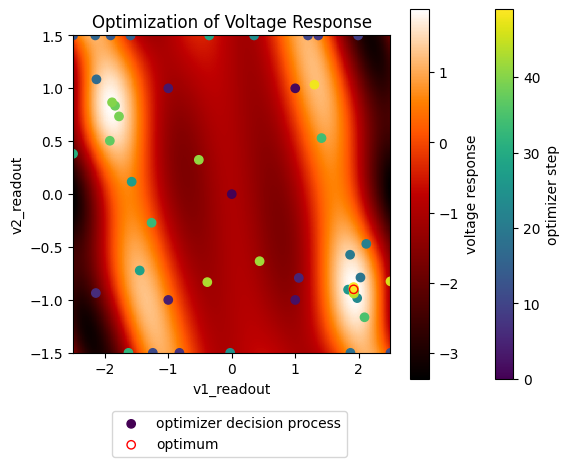

In [9]:
fig, ax = plt.subplots()
cb0 = cb1 = None
try:
    plot_optim_live(expt, x0, xf, y0, yf)
except KeyboardInterrupt:
    expt.stop()

In [10]:
expt.__dict__

{'runinfo': <pyscan.measurement.run_info.RunInfo at 0x214ec0a0590>,
 'devices': <itemattribute.item_attribute.ItemAttribute at 0x214d90d2510>,
 'expt_thread': <Thread(Thread-3 (run), started daemon 36316)>,
 'iteration': array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
        26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.,
        39., 40., 41., 42., 43., 44., 45., 46., 47., 48., 49., 50.]),
 'v1_readout': array([ 0.        ,  1.        ,  1.        , -1.        , -1.        ,
         1.05594844, -2.1408841 , -0.82440357,  1.36272511,  1.98992492,
         1.19993983, -1.24342864,  2.5       , -2.5       , -1.90798575,
        -1.59402524, -2.14978645, -2.13166672,  1.86908825,  2.02726049,
         1.863753  ,  2.11901634,  1.90373048,  1.97549451,  0.35185137,
        -0.0250788 ,  1.83225663, -1.57648413, -1.44976025, -0.35536557,
         1.93027537, -2.5       , -1.62

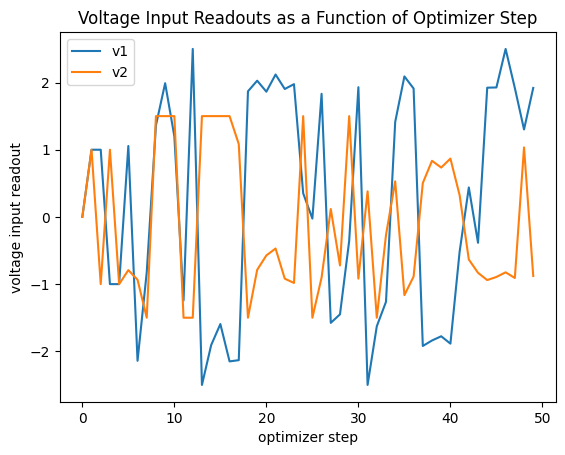

In [11]:
plt.plot(list(zip(expt.v1_readout, expt.v2_readout)))
plt.legend(['v1', 'v2'])
plt.xlabel("optimizer step")
plt.ylabel("voltage input readout")
plt.title("Voltage Input Readouts as a Function of Optimizer Step");

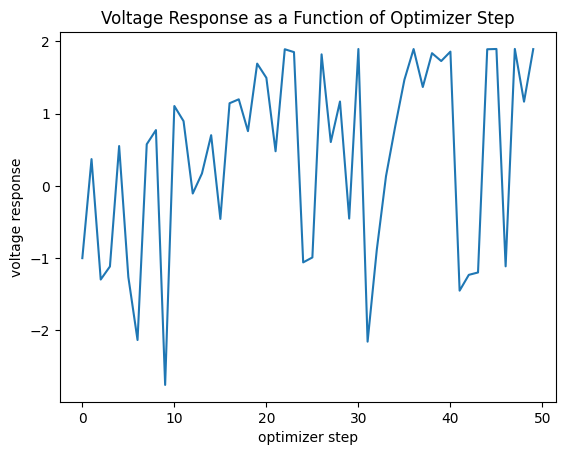

In [12]:
plt.plot(expt.vf)
plt.xlabel("optimizer step")
plt.ylabel("voltage response")
plt.title("Voltage Response as a Function of Optimizer Step");

In [13]:
def plot_optim_pcm(x0, xf, y0, yf):
    fig, ax = plt.subplots()
    x, y = np.mgrid[x0:xf:.01, y0:yf:.01]
    z = np.array(voltage_response(np.ravel(x), np.ravel(y)))
    z = z.reshape(x.shape)
    opt_arg = np.unravel_index(np.argmax(z, axis=None), z.shape)
    ax.set_xlim([x0, xf])
    ax.set_ylim([y0, yf])
    pcm = ax.pcolormesh(x, y, z, cmap='gist_heat')
    scatter = ax.scatter(expt.v1_readout, expt.v2_readout, c=range(len(expt.v1_readout)),
                         cmap='viridis')
    ax.scatter(x[opt_arg], y[opt_arg], marker='o', facecolors='none', color='r')
    ax.set_box_aspect(1)
    fig.colorbar(scatter, label="optimizer step")
    fig.colorbar(pcm, label="voltage response")
    ax.legend(["optimizer decision process", "optimum"], loc='lower left', bbox_to_anchor=(.1, -.35))
    ax.set_xlabel("v1_readout")
    ax.set_ylabel("v2_readout")
    ax.set_title("Optimization of Voltage Response")

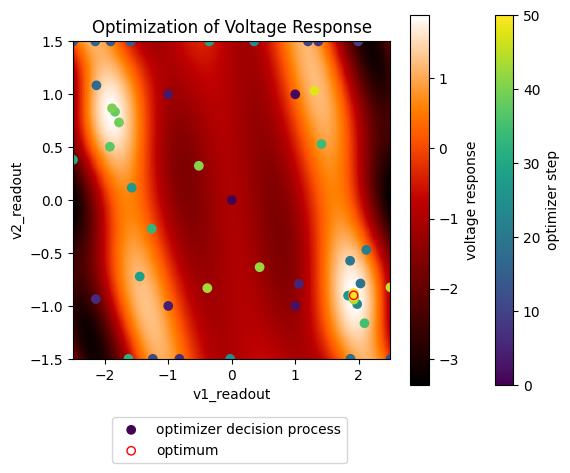

In [14]:
plot_optim_pcm(x0, xf, y0, yf)